In [1]:
import sys
import os

# Add project root to path
sys.path.append(os.path.abspath(".."))

In [2]:
import numpy as np
import imageio.v3 as iio
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from lpfun import Transform

from core.utils import vander, vander_1d, make_dual_update, split_frames_into_blocks
from core.video import reconstruct_video

In [3]:
video_raw = iio.imread("../sources/drosophila_1slice.y4m")
video_raw = video_raw[:, :, :, 0]
nx, ny = 100, 100
video = video_raw[:, :nx, :ny]

In [4]:
# Hyperparameters
lp_degree = 1.0
block_size = 10
cutoff = None
poly_degree = 5
t_degree = 20
dtype = "float16"

In [5]:
video_min, video_max = video.min(), video.max()
video = (video - video_min) / (video_max - video_min)
rescale = lambda x: (video_max - video_min) * x + video_min

In [6]:
# Recreating blocks object
blocks, nrows, ncols = split_frames_into_blocks(video, block_size)

# blocks has shape (F, n_rows, n_cols, block_size, block_size)
print(blocks.shape)

# Recreate X_design
k = np.arange(block_size)
x = np.cos(np.pi * k / (block_size - 1))
y = np.cos(np.pi * k / (block_size - 1))
X, Y = np.meshgrid(y, x)
coords = np.column_stack([X.ravel(), Y.ravel()])
t = Transform(2, poly_degree, lp_degree, basis="chebyshev", report=False)
X_design = vander(poly_degree, coords, t._A)

# Recreate t_design_matrix
k_time = np.arange(blocks.shape[0])
time = np.cos(np.pi * k_time / (blocks.shape[0] - 1))
t_design_matrix = vander_1d(time, t_degree)  # has shape (n_frames, n_coeffs_per_frame)

(31, 10, 10, 10, 10)



In [7]:
# Need to update path to the directory where you're saving the coefficients `.npy` file to.
# Load naming scheme should match Save naming scheme - shouldn't need to change anything
c_t = np.load(
    "../results/video/drosophila_1slice/coefficients/coefficients__bs=%s__cutoff=%s__lp=%s__poly_deg=%s__t_degree=%s__dtype=%s.npy"
    % (block_size, cutoff, lp_degree, poly_degree, t_degree, dtype),
    allow_pickle=False,
)

In [8]:
# video_rec has shape (n_frames, n_rows * block_size, n_cols * block_size)
video_rec_load = reconstruct_video(
    video, block_size, c_t, X_design, t_design_matrix, rescale
)

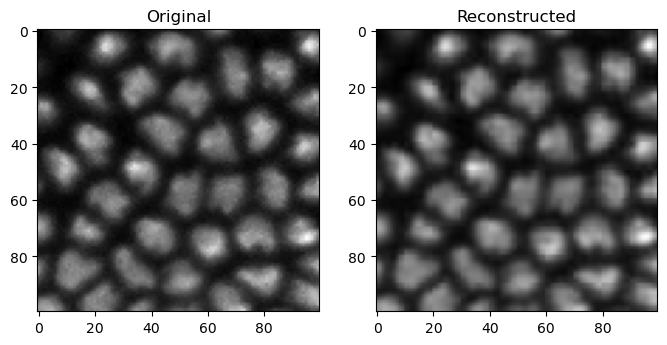

In [9]:
# To view video: calling make_update function defined in utils.py - next cell plays the video
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

im_orig = ax[0].imshow(video[0], cmap="gray")
ax[0].set_title("Original")

im_rec = ax[1].imshow(video_rec_load[0], cmap="gray")
ax[1].set_title("Reconstructed")

update = make_dual_update(video, video_rec_load, im_orig, im_rec)
ani = animation.FuncAnimation(
    fig, update, frames=len(video), interval=200, blit=True
)

In [10]:
from IPython.display import HTML
HTML(ani.to_jshtml())